# ColourAnalyser
`capabilities/analysis/colour_analyser.py`

Computes a full HSV colour health profile from a plant image.  
**No model download. Pure OpenCV. < 10 ms per image.**

| Signal | What it means |
|--------|---------------|
| `green_ratio` | Fraction of healthy green pixels — high = healthy canopy |
| `yellow_ratio` | Fraction of yellowing pixels — elevated = chlorosis / N deficiency |
| `brown_ratio` | Fraction of brown/necrotic pixels — elevated = disease or drought |
| `health_index` | Composite score [0–1] — higher = healthier |
| `dominant_hue` | Most frequent hue value (0–179 OpenCV scale) |
| `saturation_mean` | Mean saturation — low = pale/etiolated, high = vibrant |
| `brightness_mean` | Mean brightness — low = dark or underexposed |

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from capabilities.analysis.colour_analyser import ColourAnalyser
from sprout_detection.utils.image_gen import make_sprout_image, make_bare_soil_image

analyser = ColourAnalyser()
print('ColourAnalyser ready')

ColourAnalyser ready


## Generate test images

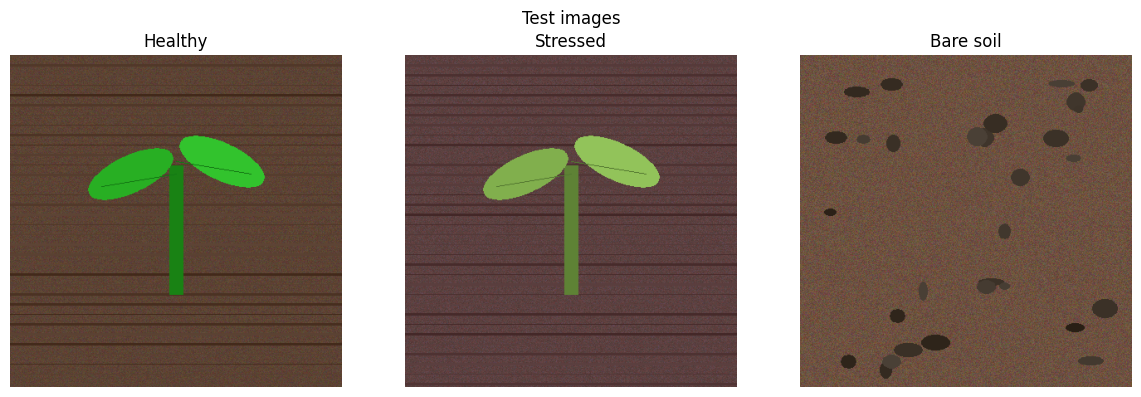

In [2]:
import tempfile

tmp = tempfile.mkdtemp()
healthy_path = os.path.join(tmp,'healthy.png')
stressed_path = os.path.join(tmp,'stressed.png')
bare_path = os.path.join(tmp,'bare.png')

make_sprout_image(healthy_path, seed=1)

make_sprout_image(stressed_path, seed=2)
img = cv2.imread(stressed_path)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
hsv[:,:,0] -= 15
hsv[:,:,1] *= 0.7
cv2.imwrite(stressed_path, cv2.cvtColor(np.clip(hsv,0,255).astype(np.uint8), cv2.COLOR_HSV2BGR))

make_bare_soil_image(bare_path, seed=3)

fig, axes = plt.subplots(1,3,figsize=(12,4))
for ax,(path,title) in zip(axes,[(healthy_path,'Healthy'),(stressed_path,'Stressed'),(bare_path,'Bare soil')]):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(title); ax.axis('off')

plt.suptitle('Test images')
plt.tight_layout()
plt.show()

## Basic usage — analyse a single image

In [4]:
result = analyser.analyse(healthy_path)

print(f'Health index   : {result.health_index:.3f}')
print(f'Green ratio    : {result.green_ratio:.3f}')
print(f'Yellow ratio   : {result.yellow_ratio:.3f}')
print(f'Brown ratio    : {result.brown_ratio:.3f}')
print(f'Dominant hue   : {result.dominant_hue}  (0=red, 60=yellow, 120=green)')
print(f'Saturation mean: {result.saturation_mean:.1f}')
print(f'Brightness mean: {result.brightness_mean:.1f}')
print(f'Summary        : {result.summary}')
print(f'Inference time : {result.duration_ms:.1f} ms')

Health index   : 0.031
Green ratio    : 0.066
Yellow ratio   : 0.093
Brown ratio    : 0.621
Dominant hue   : 11  (0=red, 60=yellow, 120=green)
Saturation mean: 119.7
Brightness mean: 95.4
Summary        : Severely stressed — 6.6% green, 9.3% yellowing, 62.1% browning
Inference time : 12.8 ms


## Compare healthy vs stressed vs bare

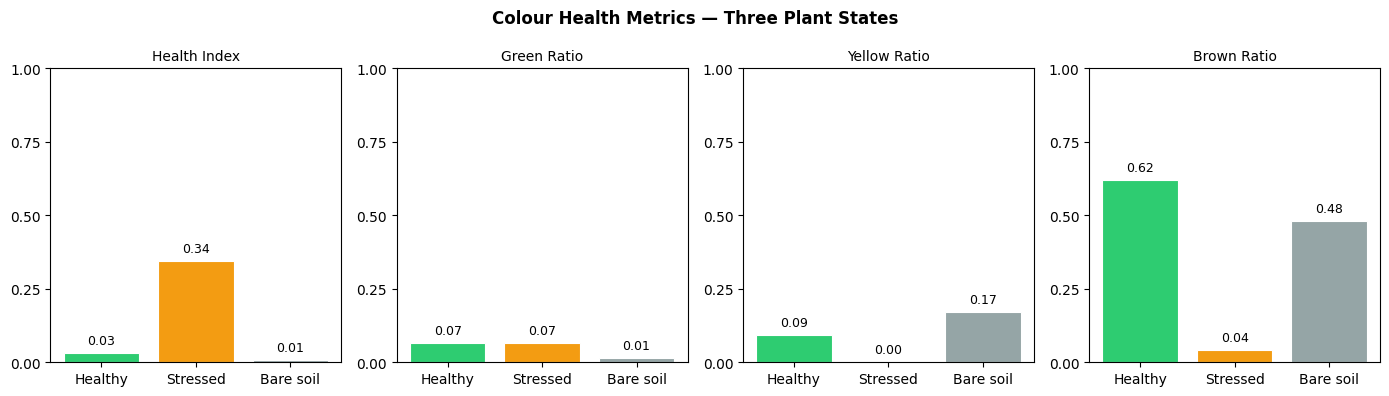

In [5]:
results = {
    'Healthy' : analyser.analyse(healthy_path),
    'Stressed': analyser.analyse(stressed_path),
    'Bare soil': analyser.analyse(bare_path),
}

metrics = ['health_index', 'green_ratio', 'yellow_ratio', 'brown_ratio']
labels  = list(results.keys())
colors  = ['#2ecc71', '#f39c12', '#95a5a6']

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4))
for ax, metric in zip(axes, metrics):
    vals = [getattr(r, metric) for r in results.values()]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Colour Health Metrics — Three Plant States', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## All colour band ratios

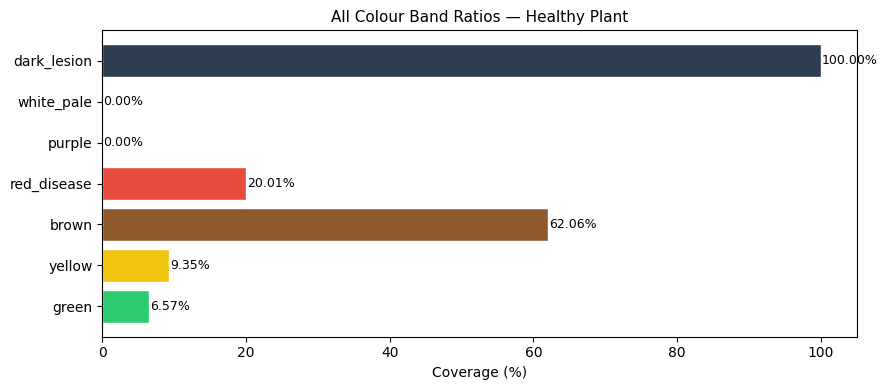

In [6]:
result = analyser.analyse(healthy_path)

bands = result.band_ratios
band_names = list(bands.keys())
band_vals  = [bands[k] * 100 for k in band_names]

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#2ecc71','#f1c40f','#8e5a2d','#e74c3c','#9b59b6','#ecf0f1','#2c3e50']
bars = ax.barh(band_names, band_vals, color=bar_colors[:len(band_names)], edgecolor='white')
for bar, val in zip(bars, band_vals):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
ax.set_xlabel('Coverage (%)')
ax.set_title('All Colour Band Ratios — Healthy Plant', fontsize=11)
plt.tight_layout()
plt.show()

## Hue histogram — what colours dominate?

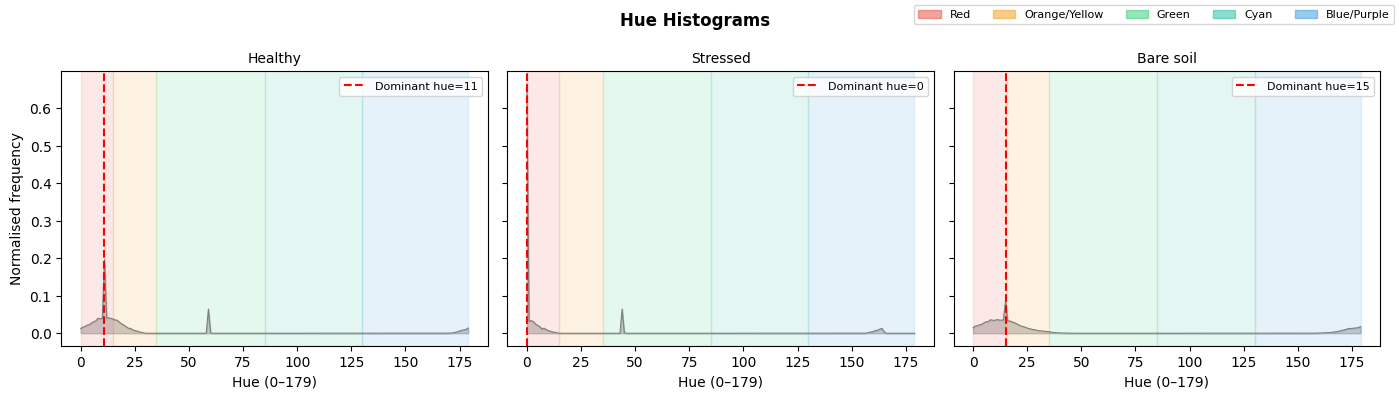

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

hue_regions = [
    (0,  15,  '#e74c3c', 'Red'),
    (15, 35,  '#f39c12', 'Orange/Yellow'),
    (35, 85,  '#2ecc71', 'Green'),
    (85, 130, '#1abc9c', 'Cyan'),
    (130,179, '#3498db', 'Blue/Purple'),
]

for ax, (name, r) in zip(axes, results.items()):
    x = np.arange(180)
    y = np.array(r.histogram_h)
    ax.fill_between(x, y, alpha=0.4, color='gray')
    ax.plot(x, y, color='gray', linewidth=0.8)
    # Shade hue regions
    for h_lo, h_hi, col, _ in hue_regions:
        ax.axvspan(h_lo, h_hi, alpha=0.12, color=col)
    ax.axvline(r.dominant_hue, color='red', linewidth=1.5, linestyle='--', label=f'Dominant hue={r.dominant_hue}')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Hue (0–179)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Normalised frequency')
patches = [mpatches.Patch(color=c, label=l, alpha=0.5) for _, _, c, l in hue_regions]
fig.legend(handles=patches, loc='upper right', fontsize=8, ncol=5)
plt.suptitle('Hue Histograms', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## `diff()` — track change between two time points

In [8]:
r_before = results['Healthy']
r_after  = results['Stressed']

delta = analyser.diff(r_before, r_after)

print('Change from Healthy → Stressed:')
for field, change in delta.items():
    arrow = '▲' if change > 0 else ('▼' if change < 0 else '=')
    print(f'  {field:<20} {arrow}  {change:+.4f}')

Change from Healthy → Stressed:
  green_ratio          =  +0.0000
  yellow_ratio         ▼  -0.0935
  brown_ratio          ▼  -0.5790
  health_index         ▲  +0.3138
  saturation_mean      ▼  -34.6428
  brightness_mean      ▼  -0.6127


## Using a segmentation mask (analyse only plant pixels)

In [9]:
from capabilities.segmentation.hsv_segmentor import HSVSegmentor

seg = HSVSegmentor()
seg_result = seg.segment(healthy_path, profile='green_plant')

# Analyse only the segmented plant region — excludes pot and background
result_masked = analyser.analyse(healthy_path, mask=seg_result.mask)
result_full   = analyser.analyse(healthy_path)

print('With mask (plant pixels only):')
print(f'  health_index : {result_masked.health_index:.3f}')
print(f'  green_ratio  : {result_masked.green_ratio:.3f}')
print()
print('Without mask (whole image):')
print(f'  health_index : {result_full.health_index:.3f}')
print(f'  green_ratio  : {result_full.green_ratio:.3f}')

With mask (plant pixels only):
  health_index : 0.995
  green_ratio  : 0.004

Without mask (whole image):
  health_index : 0.031
  green_ratio  : 0.066


In [10]:
result = analyser.analyse(healthy_path, mask=seg_result.mask)

print(f'Health index   : {result.health_index:.3f}')
print(f'Green ratio    : {result.green_ratio:.3f}')
print(f'Yellow ratio   : {result.yellow_ratio:.3f}')
print(f'Brown ratio    : {result.brown_ratio:.3f}')
print(f'Dominant hue   : {result.dominant_hue}  (0=red, 60=yellow, 120=green)')
print(f'Saturation mean: {result.saturation_mean:.1f}')
print(f'Brightness mean: {result.brightness_mean:.1f}')
print(f'Summary        : {result.summary}')
print(f'Inference time : {result.duration_ms:.1f} ms')

Health index   : 0.995
Green ratio    : 0.004
Yellow ratio   : 0.000
Brown ratio    : 0.000
Dominant hue   : 59  (0=red, 60=yellow, 120=green)
Saturation mean: 204.1
Brightness mean: 170.1
Summary        : Healthy — 0.4% green
Inference time : 15.1 ms


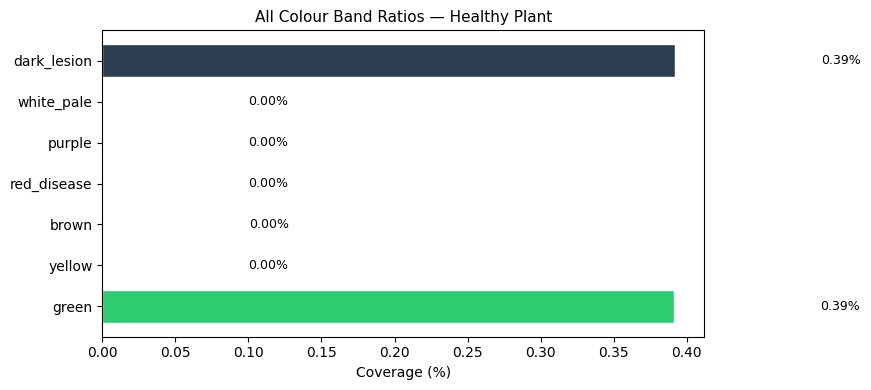

In [11]:
result = analyser.analyse(healthy_path, mask=seg_result.mask)

bands = result.band_ratios
band_names = list(bands.keys())
band_vals  = [bands[k] * 100 for k in band_names]

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#2ecc71','#f1c40f','#8e5a2d','#e74c3c','#9b59b6','#ecf0f1','#2c3e50']
bars = ax.barh(band_names, band_vals, color=bar_colors[:len(band_names)], edgecolor='white')
for bar, val in zip(bars, band_vals):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
ax.set_xlabel('Coverage (%)')
ax.set_title('All Colour Band Ratios — Healthy Plant', fontsize=11)
plt.tight_layout()
plt.show()